In [44]:
# Run this FIRST in Google Colab
!pip install shap --quiet

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report,
                              ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [46]:
from google.colab import files

# This will open a file picker — select your CSV
uploaded = files.upload()

# Load into dataframe
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f"✅ Dataset loaded! Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Saving hr_predictions.csv to hr_predictions (1).csv
✅ Dataset loaded! Shape: (1470, 35)
Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [47]:
print("=== Dataset Info ===")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print("\n--- Attrition Count ---")
print(df['Attrition'].value_counts())
print(f"\nAttrition Rate: {df['Attrition'].value_counts(normalize=True)['Yes']*100:.1f}%")
df.describe()

=== Dataset Info ===
Shape: (1470, 35)
Missing values: 0
Duplicates: 0

--- Attrition Count ---
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.1%


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [48]:
# Step 1: Keep raw original BEFORE anything
df_orig = df.copy()   # ← Has 'Yes'/'No' strings — correct for EDA

# Step 2: Drop useless columns from df only (not df_orig)
df.drop(['EmployeeCount', 'Over18', 'StandardHours'],
        axis=1, inplace=True, errors='ignore')

# Step 3: Encode target column in df only
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Step 4: Encode all categorical columns in df only
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(f"✅ Cleaned! Shape: {df.shape}")
print(f"df_orig Attrition sample: {df_orig['Attrition'].unique()}")  # should show Yes/No
print(f"df Attrition sample: {df['Attrition'].unique()}")            # should show 0/1
df.head()

✅ Cleaned! Shape: (1470, 32)
df_orig Attrition sample: ['Yes' 'No']
df Attrition sample: [1 0]


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,5,4,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,7,1,...,3,4,1,6,3,3,2,2,2,2


In [49]:
# FIXED - add errors='ignore'
df.drop(['EmployeeCount', 'Over18', 'StandardHours'],
        axis=1, inplace=True, errors='ignore')

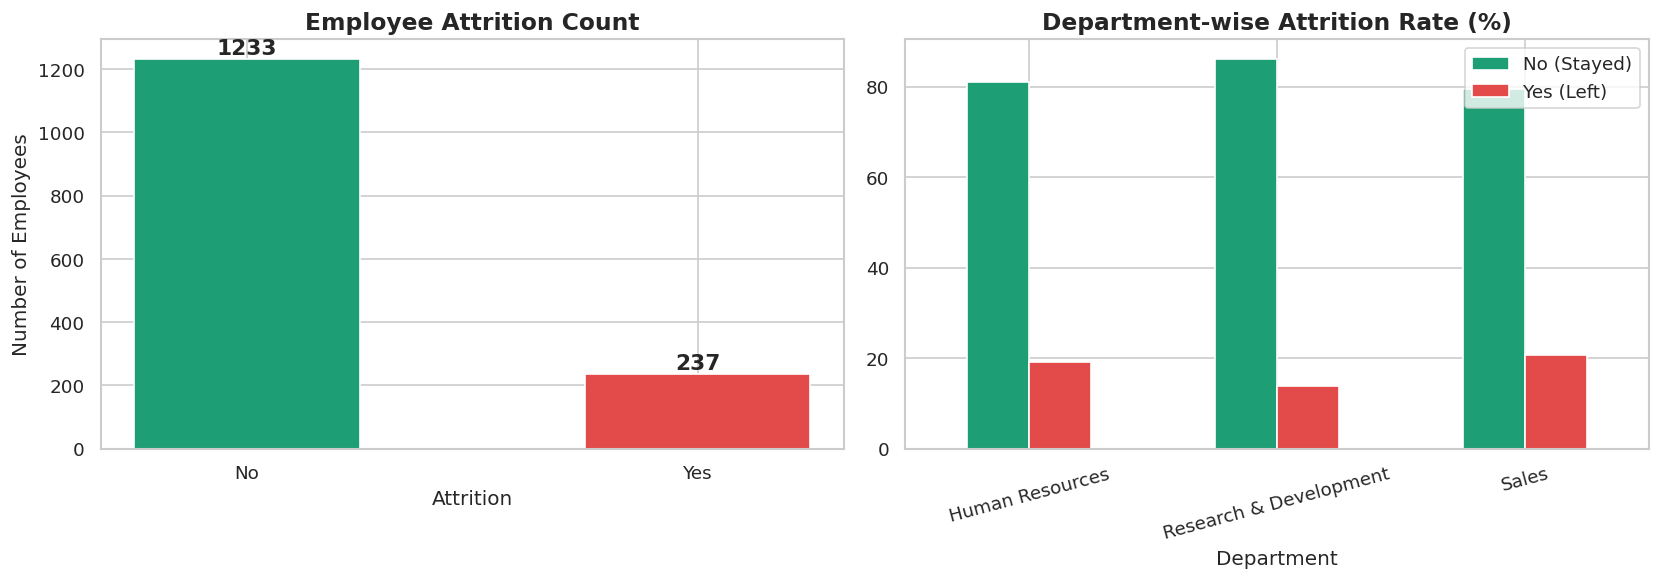

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Overall attrition count
counts = df_orig['Attrition'].value_counts()
axes[0].bar(counts.index, counts.values,
           color=['#1D9E75', '#E24B4A'], width=0.5, edgecolor='white')
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v+15, str(v), ha='center', fontsize=13, fontweight='bold')
axes[0].set_title('Employee Attrition Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Number of Employees')

# Plot 2: Department-wise attrition rate
dept = df_orig.groupby('Department')['Attrition'].value_counts(
    normalize=True).unstack() * 100
dept.plot(kind='bar', ax=axes[1], color=['#1D9E75', '#E24B4A'], edgecolor='white')
axes[1].set_title('Department-wise Attrition Rate (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Department')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
axes[1].legend(['No (Stayed)', 'Yes (Left)'])

plt.tight_layout()
plt.show()

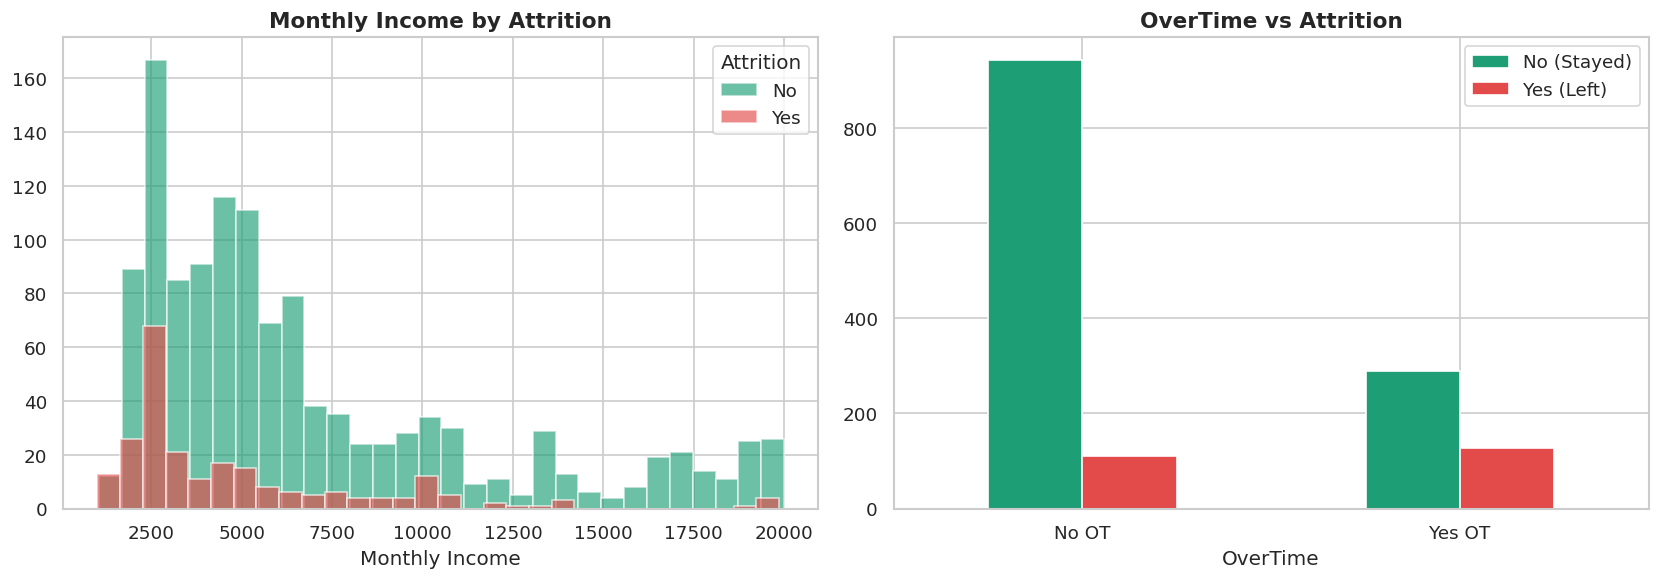

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 3: Monthly income by attrition
for label, color in [('No', '#1D9E75'), ('Yes', '#E24B4A')]:
    df_orig[df_orig['Attrition']==label]['MonthlyIncome'].hist(
        bins=30, ax=axes[0], alpha=0.65, color=color,
        label=label, edgecolor='white')
axes[0].set_title('Monthly Income by Attrition', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Monthly Income')
axes[0].legend(title='Attrition')

# Plot 4: OverTime vs Attrition
ot = df_orig.groupby(['OverTime', 'Attrition']).size().unstack()
ot.plot(kind='bar', ax=axes[1], color=['#1D9E75', '#E24B4A'], edgecolor='white')
axes[1].set_title('OverTime vs Attrition', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['No OT', 'Yes OT'], rotation=0)
axes[1].legend(['No (Stayed)', 'Yes (Left)'])

plt.tight_layout()
plt.show()

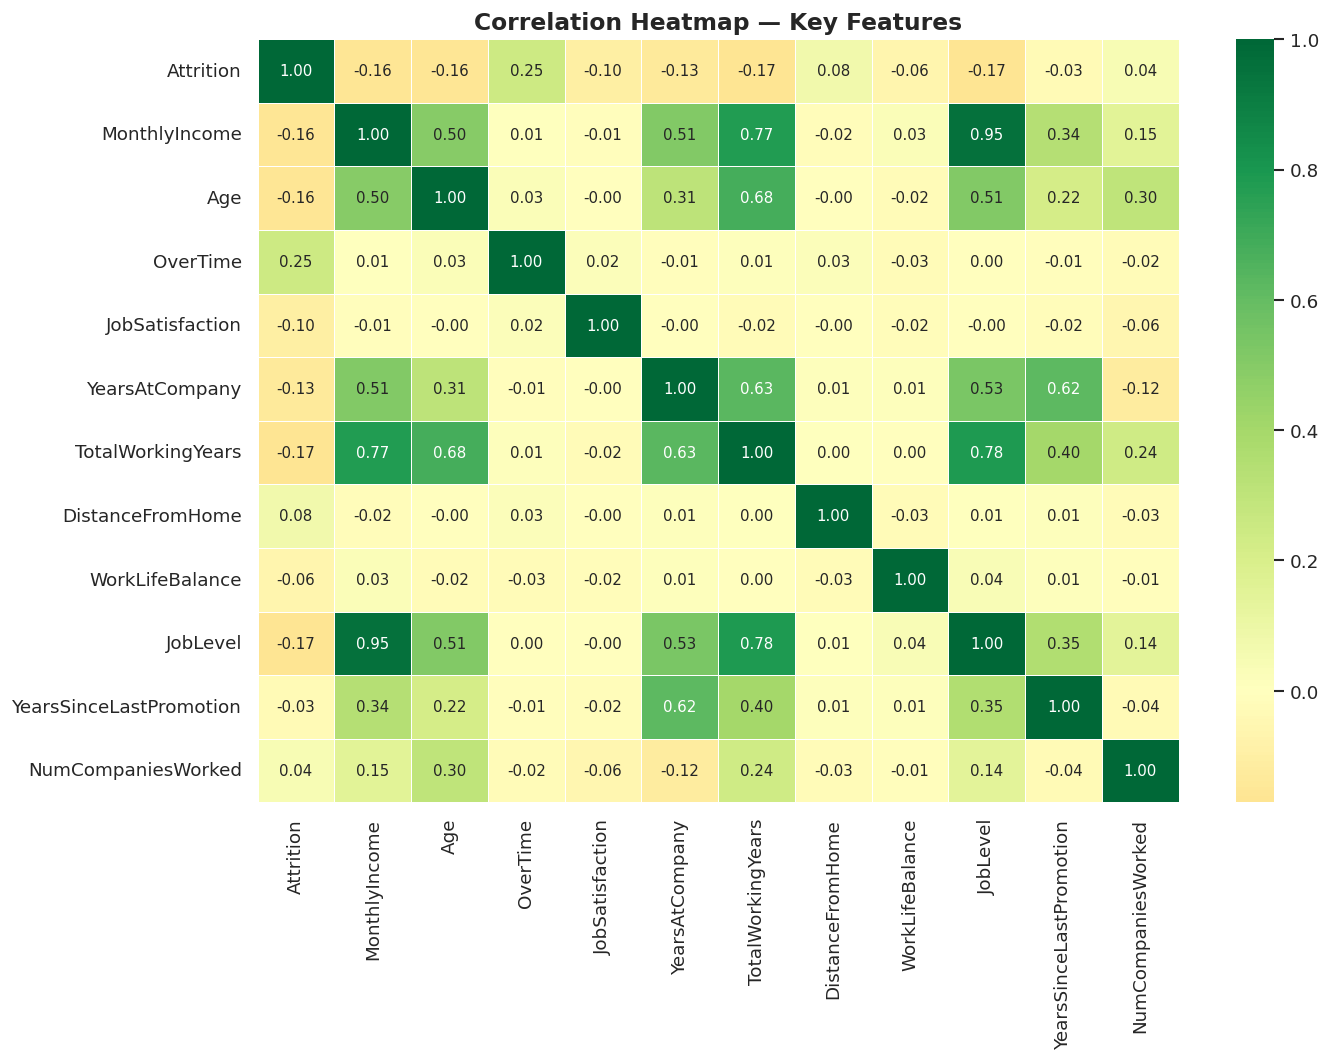

In [52]:
top_cols = ['Attrition', 'MonthlyIncome', 'Age', 'OverTime',
            'JobSatisfaction', 'YearsAtCompany', 'TotalWorkingYears',
            'DistanceFromHome', 'WorkLifeBalance', 'JobLevel',
            'YearsSinceLastPromotion', 'NumCompaniesWorked']

plt.figure(figsize=(12, 9))
sns.heatmap(df[top_cols].corr(),
            annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Correlation Heatmap — Key Features',
         fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

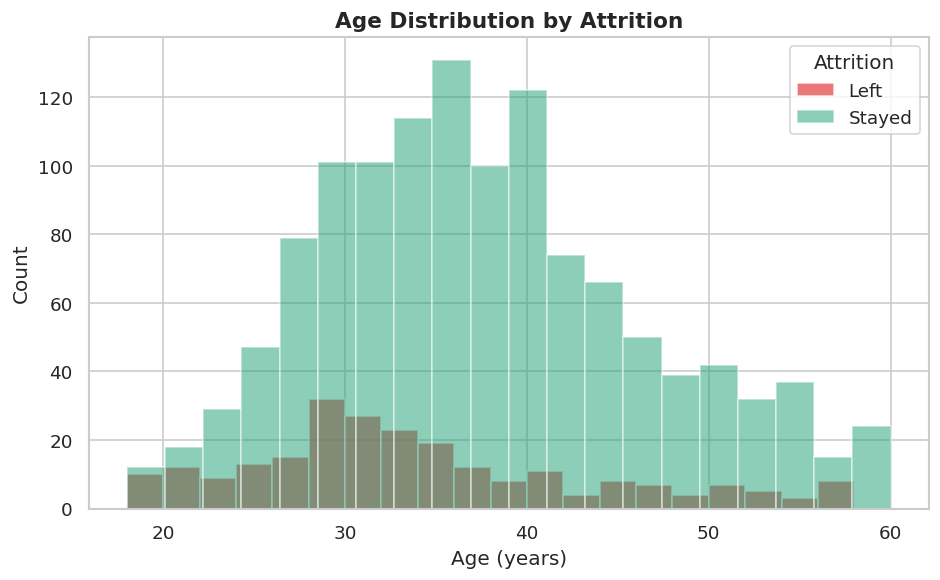

In [53]:
plt.figure(figsize=(8, 5))
df_orig[df_orig['Attrition']=='Yes']['Age'].hist(
    bins=20, alpha=0.75, color='#E24B4A', label='Left', edgecolor='white')
df_orig[df_orig['Attrition']=='No']['Age'].hist(
    bins=20, alpha=0.5, color='#1D9E75', label='Stayed', edgecolor='white')
plt.title('Age Distribution by Attrition', fontsize=13, fontweight='bold')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.legend(title='Attrition')
plt.tight_layout()
plt.show()

In [54]:
# Separate features (X) and target (y)
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# 80% train, 20% test — stratify keeps class ratio balanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"✅ Train size : {X_train.shape}")
print(f"   Test size  : {X_test.shape}")
print(f"   Attrition in train: {y_train.mean()*100:.1f}%")
print(f"   Attrition in test : {y_test.mean()*100:.1f}%")

✅ Train size : (1176, 31)
   Test size  : (294, 31)
   Attrition in train: 16.2%
   Attrition in test : 16.0%


=== Logistic Regression Results ===
Accuracy : 86.1%

Classification Report:
              precision    recall  f1-score   support

 No (Stayed)       0.87      0.99      0.92       247
  Yes (Left)       0.75      0.19      0.31        47

    accuracy                           0.86       294
   macro avg       0.81      0.59      0.61       294
weighted avg       0.85      0.86      0.82       294



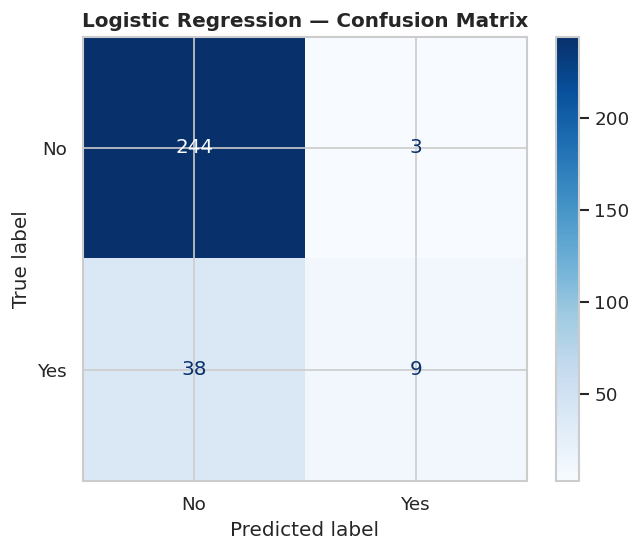

In [55]:
# Train the model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== Logistic Regression Results ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr)*100:.1f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=['No (Stayed)', 'Yes (Left)']))

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(
    lr, X_test, y_test,
    display_labels=['No', 'Yes'],
    cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix', fontweight='bold')
plt.show()

=== Decision Tree Results ===
Accuracy : 84.0%

Classification Report:
              precision    recall  f1-score   support

 No (Stayed)       0.86      0.96      0.91       247
  Yes (Left)       0.50      0.19      0.28        47

    accuracy                           0.84       294
   macro avg       0.68      0.58      0.59       294
weighted avg       0.80      0.84      0.81       294



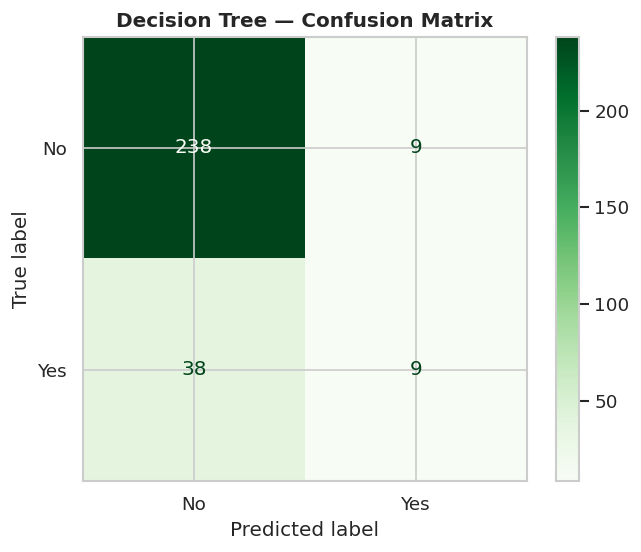

In [56]:
# Train Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("=== Decision Tree Results ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt)*100:.1f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt,
      target_names=['No (Stayed)', 'Yes (Left)']))

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(
    dt, X_test, y_test,
    display_labels=['No', 'Yes'],
    cmap='Greens')
plt.title('Decision Tree — Confusion Matrix', fontweight='bold')
plt.show()

In [57]:
lr_acc = accuracy_score(y_test, y_pred_lr)
dt_acc = accuracy_score(y_test, y_pred_dt)

print("╔══════════════════════════════════╗")
print("║      MODEL COMPARISON            ║")
print("╠══════════════════════════════════╣")
print(f"║ Logistic Regression : {lr_acc*100:.1f}%      ║")
print(f"║ Decision Tree       : {dt_acc*100:.1f}%      ║")
print("╚══════════════════════════════════╝")

best = "Logistic Regression" if lr_acc > dt_acc else "Decision Tree"
print(f"\n🏆 Best model: {best}")

╔══════════════════════════════════╗
║      MODEL COMPARISON            ║
╠══════════════════════════════════╣
║ Logistic Regression : 86.1%      ║
║ Decision Tree       : 84.0%      ║
╚══════════════════════════════════╝

🏆 Best model: Logistic Regression


In [58]:
# Keep original copy FIRST — before any changes
df_orig = df.copy()   # ← MOVE THIS TO THE TOP

# Drop useless columns
df.drop(['EmployeeCount', 'Over18', 'StandardHours'],
        axis=1, inplace=True, errors='ignore')

# Encode target column: Yes=1, No=0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Encode all categorical columns
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(f"✅ Cleaned! Shape: {df.shape}")
df.head()

✅ Cleaned! Shape: (1470, 32)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,NaN,2,1102,2,1,2,1,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,NaN,1,279,1,8,1,1,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,NaN,2,1373,1,2,2,4,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,NaN,1,1392,1,3,4,1,5,4,...,3,3,0,8,3,3,8,7,3,0
4,27,NaN,2,591,1,2,1,3,7,1,...,3,4,1,6,3,3,2,2,2,2


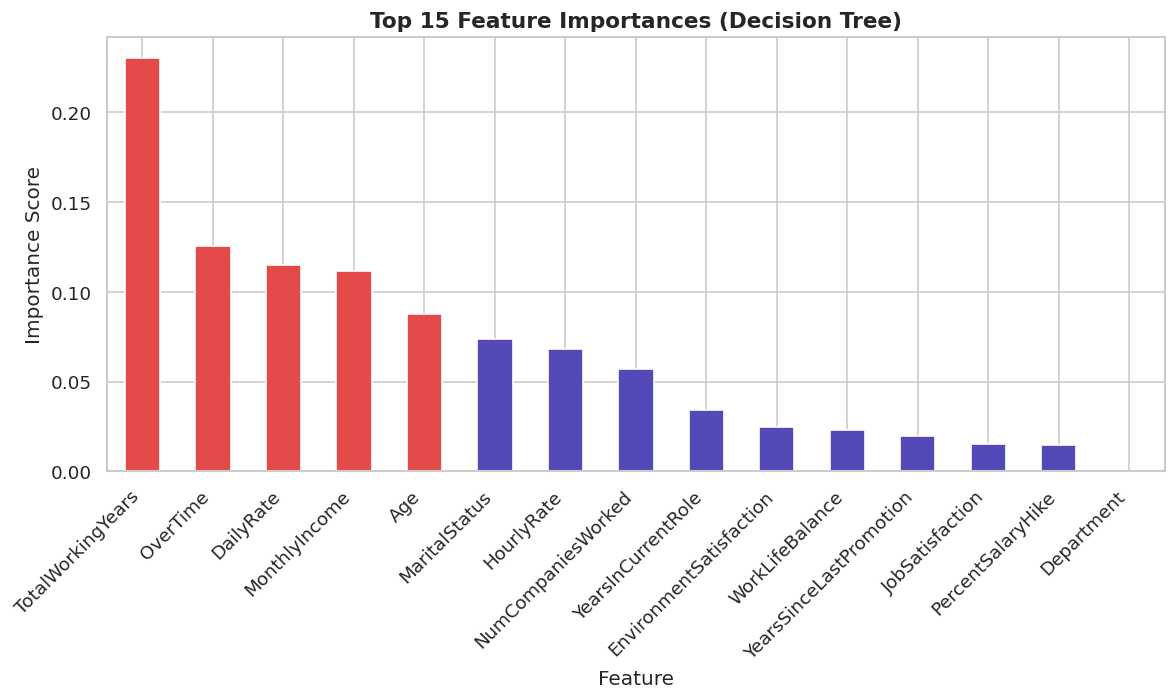


Top 5 Attrition Drivers:
  1. TotalWorkingYears: 0.2304
  2. OverTime: 0.1257
  3. DailyRate: 0.1147
  4. MonthlyIncome: 0.1118
  5. Age: 0.0876


In [59]:
feat_imp = pd.Series(
    dt.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors_bar = ['#E24B4A' if i < 5 else '#534AB7'
              for i in range(len(feat_imp))]
feat_imp.plot(kind='bar', color=colors_bar, edgecolor='white')
plt.title('Top 15 Feature Importances (Decision Tree)',
         fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 Attrition Drivers:")
for i, (feat, score) in enumerate(feat_imp.head(5).items(), 1):
    print(f"  {i}. {feat}: {score:.4f}")

In [60]:
from google.colab import files

# Save cleaned dataset (use this in Power BI)
df.to_csv('hr_cleaned.csv', index=False)

# Save predictions
results = X_test.copy()
results['Actual']   = y_test.values
results['Pred_LR']  = y_pred_lr
results['Pred_DT']  = y_pred_dt
results.to_csv('hr_predictions.csv', index=False)

# Download both files
files.download('hr_cleaned.csv')
files.download('hr_predictions.csv')

print("✅ Files downloaded!")
print(f"LR Accuracy : {accuracy_score(y_test, y_pred_lr)*100:.1f}%")
print(f"DT Accuracy : {accuracy_score(y_test, y_pred_dt)*100:.1f}%")
print(f"Top Feature : {feat_imp.index[0]}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloaded!
LR Accuracy : 86.1%
DT Accuracy : 84.0%
Top Feature : TotalWorkingYears


SHAP values shape : (294, 31, 2)
X_test shape      : (294, 31)


<Figure size 1200x720 with 0 Axes>

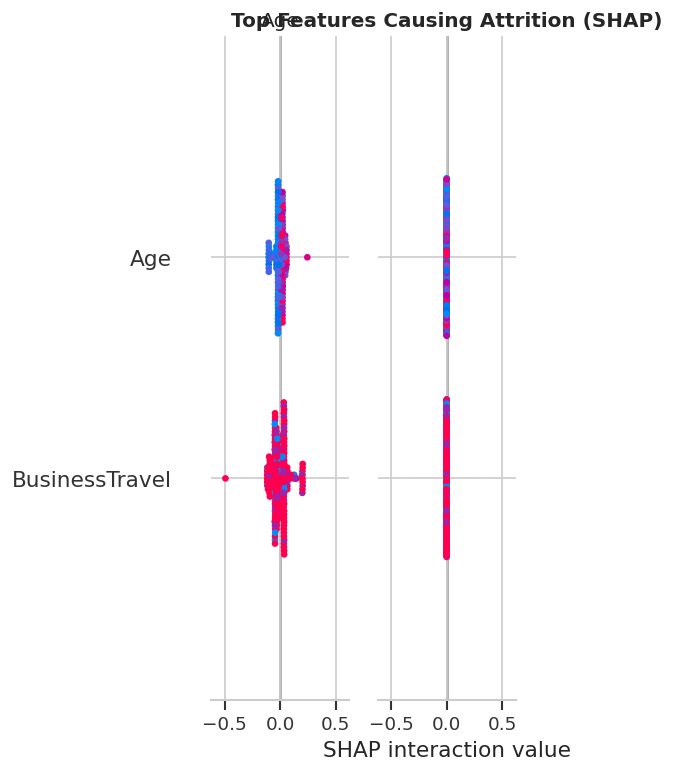

<Figure size 1200x720 with 0 Axes>

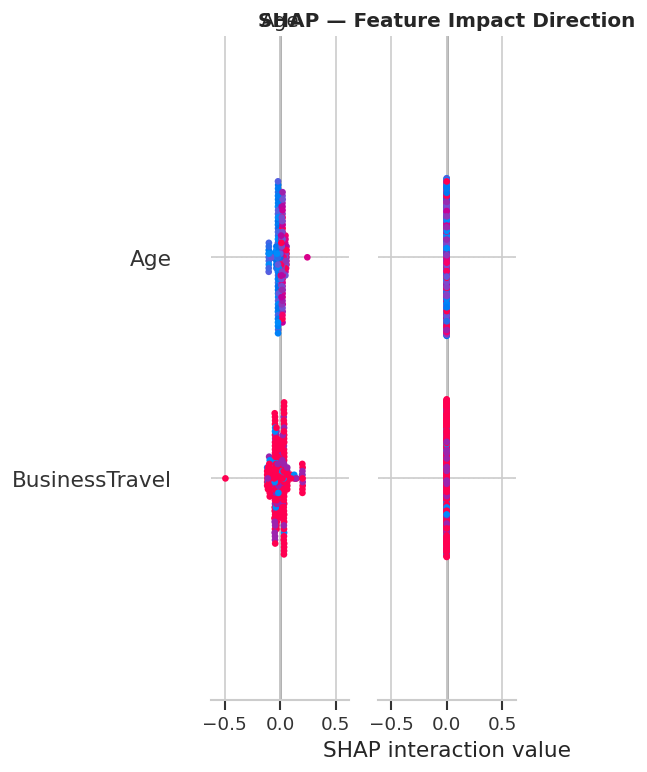

In [61]:
# ══════════════════════════════════════════════
# SHAP ANALYSIS — COMPLETE FIXED VERSION
# ══════════════════════════════════════════════

explainer = shap.TreeExplainer(dt)
shap_values = explainer.shap_values(X_test)

# Fix for ALL shap versions
if isinstance(shap_values, list):
    sv = shap_values[1]    # older shap version
else:
    sv = shap_values       # newer shap version

print(f"SHAP values shape : {sv.shape}")
print(f"X_test shape      : {X_test.shape}")
# Both must show same number — e.g. (294, 31)

# ── Plot 1: SHAP Bar Chart ──────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_test,
                  plot_type="bar",
                  show=False)
plt.title('Top Features Causing Attrition (SHAP)', fontweight='bold')
plt.tight_layout()
plt.show()

# ── Plot 2: SHAP Dot Plot ───────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_test, show=False)
plt.title('SHAP — Feature Impact Direction', fontweight='bold')
plt.tight_layout()
plt.show()